<a href="https://colab.research.google.com/github/pudiniman/INTELIGENCIA-ARTIFICIAL/blob/main/EXAMEN%20MEDIO%20CURSO%202177985.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligencia Artificial
# EXAMEN MEDIO CURSO
#- Héctor Alexander Salazar Martínez 2177985

In [2]:
#Configuración inicial y carga de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Cargar datos desde archivo csv
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv')

# 3. Imprime las primeras 5 filas y muestra los tipos de datos de cada columna.
print("Primeras 5 filas del DataFrame:")
print(df.head())

print("\n" + "="*50 + "\n")
print("Tipos de datos de cada columna:")
print(df.dtypes)


Primeras 5 filas del DataFrame:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


Tipos de datos de cada columna:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             obje

In [7]:
# --- Celda 3: Limpieza de Datos (Valores nulos en 'horsepower') ---

# 4. Identifica si hay valores nulos en la columna horsepower.
print("Valores nulos por columna (antes de la limpieza):")
print(df.isnull().sum())

# Calcular la mediana de la columna 'horsepower' (ignorando los valores nulos)
# Usamos np.nanmedian para calcular la mediana ignorando NaN, o pandas .median()
mediana_horsepower = df['horsepower'].median(skipna=True)

print(f"\nLa mediana de 'horsepower' es: {mediana_horsepower}")

# Reemplazar los valores nulos en 'horsepower' con la mediana calculada.
df['horsepower'].fillna(mediana_horsepower, inplace=True)

# Verificar que ya no hay valores nulos en horsepower.
print("\nValores nulos por columna (después de la limpieza):")
print(df.isnull().sum())


Valores nulos por columna (antes de la limpieza):
mpg                       0
cylinders                 0
displacement              0
horsepower                0
weight                    0
acceleration              0
model_year                0
origin                    0
name                      0
relacion_peso_potencia    0
dtype: int64

La mediana de 'horsepower' es: 93.5

Valores nulos por columna (después de la limpieza):
mpg                       0
cylinders                 0
displacement              0
horsepower                0
weight                    0
acceleration              0
model_year                0
origin                    0
name                      0
relacion_peso_potencia    0
dtype: int64


/tmp/ipykernel_428/3412228359.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(mediana_horsepower, inplace=True)


In [8]:
# --- Celda 4: Creación de nueva columna ---

# 5. Crea una nueva columna llamada `relacion_peso_potencia`
#    que sea el resultado de dividir la columna weight (peso) entre horsepower.
df['relacion_peso_potencia'] = df['weight'] / df['horsepower']

# Mostrar las primeras filas para verificar la nueva columna
print("Primeras 5 filas con la nueva columna 'relacion_peso_potencia':")
print(df[['weight', 'horsepower', 'relacion_peso_potencia']].head())


Primeras 5 filas con la nueva columna 'relacion_peso_potencia':
   weight  horsepower  relacion_peso_potencia
0    3504       130.0               26.953846
1    3693       165.0               22.381818
2    3436       150.0               22.906667
3    3433       150.0               22.886667
4    3449       140.0               24.635714


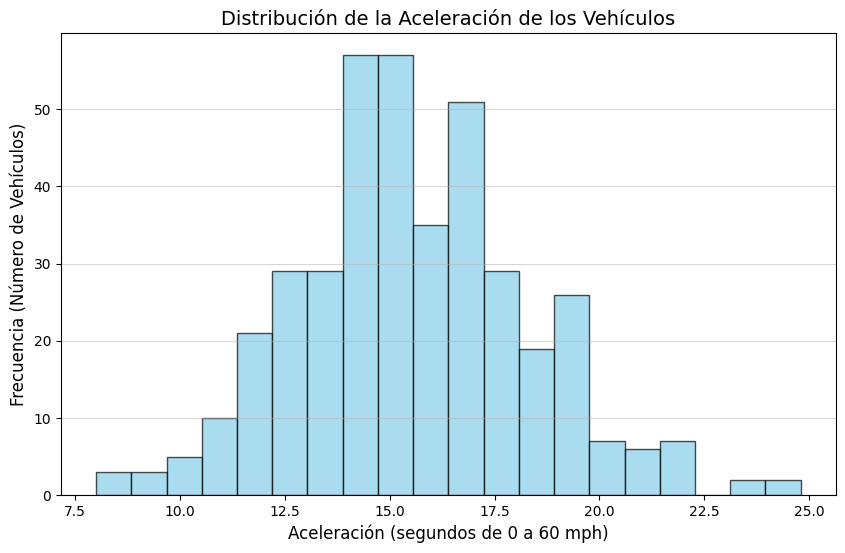

In [6]:
# --- Celda 5: Visualización - Histograma de Aceleración ---

# 1. Histograma: Muestra la distribución de la aceleración (acceleration).

plt.figure(figsize=(10, 6))
plt.hist(df['acceleration'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Distribución de la Aceleración de los Vehículos', fontsize=14)
plt.xlabel('Aceleración (segundos de 0 a 60 mph)', fontsize=12)
plt.ylabel('Frecuencia (Número de Vehículos)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()


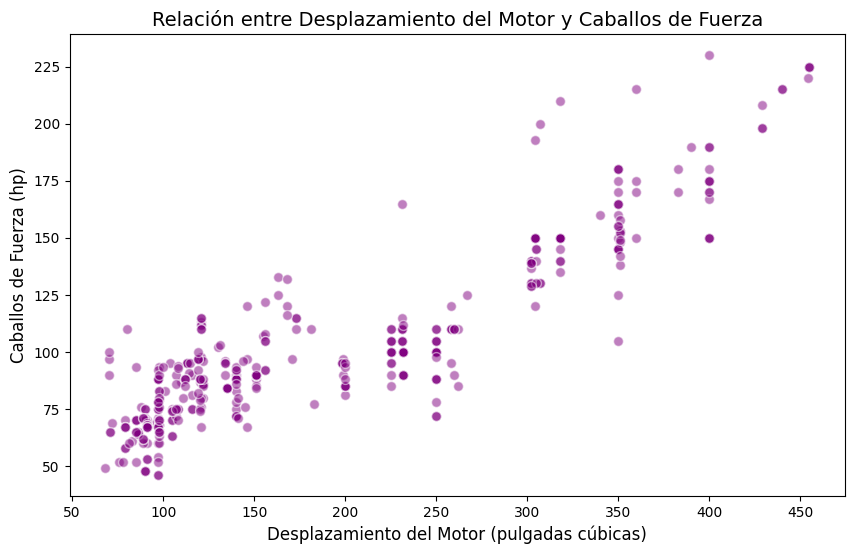

In [20]:
# --- Celda 6: Visualización - Gráfico de Dispersión ---

# 2. Gráfico de Dispersión: Desplazamiento del motor vs Caballos de fuerza.

plt.figure(figsize=(10, 6))
plt.scatter(df['displacement'], df['horsepower'], alpha=0.5, c='purple', edgecolors='w', s=50)
plt.title('Relación entre Desplazamiento del Motor y Caballos de Fuerza', fontsize=14)
plt.xlabel('Desplazamiento del Motor (pulgadas cúbicas)', fontsize=12)
plt.ylabel('Caballos de Fuerza (hp)', fontsize=12)
plt.show()


In [16]:
# --- Celda 7: Preparación para Gráfico de Barras (Versión Corregida) ---

# 3. Gráfico de Barras: Promedio de rendimiento (mpg) agrupado por país de origen.

# Verificar los valores únicos en la columna 'origin'
print("Valores únicos en 'origin':", df['origin'].unique())

# Agrupar por la columna 'origin' y calcular el promedio de 'mpg'
mpg_por_origen = df.groupby('origin')['mpg'].mean().reset_index()

# Mapear los números a nombres de países para mejor visualización
mapa_origen = {1: 'USA', 2: 'Europa', 3: 'Japón'}
mpg_por_origen['pais'] = mpg_por_origen['origin'].map(mapa_origen)

print("\nDatos agrupados por país de origen:")
print(mpg_por_origen)


Valores únicos en 'origin': ['usa' 'japan' 'europe']

Datos agrupados por país de origen:
   origin        mpg pais
0  europe  27.891429  NaN
1   japan  30.450633  NaN
2     usa  20.083534  NaN


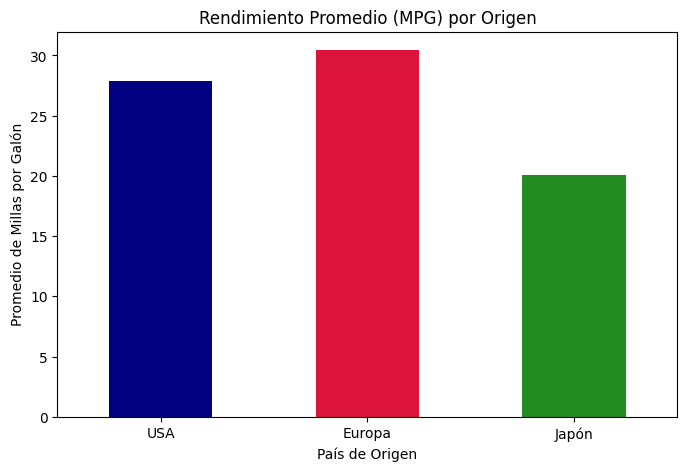

In [18]:
# --- Celda 7: Gráfico de Barras - Versión Ultra Simple (como en la imagen) ---

# Calcular el promedio de MPG agrupado por origen
resumen_origen = df.groupby('origin')['mpg'].mean()

# Crear el gráfico de barras simple
plt.figure(figsize=(8, 5))
resumen_origen.plot(kind='bar', color=['navy', 'crimson', 'forestgreen'])

# Personalizar mínimamente
plt.title('Rendimiento Promedio (MPG) por Origen')
plt.xlabel('País de Origen')
plt.ylabel('Promedio de Millas por Galón')
plt.xticks(ticks=[0, 1, 2], labels=['USA', 'Europa', 'Japón'], rotation=0)

plt.show()